## Numbers Dataset

We have a dataset of handwritten digits from 0 to 9

We need some library to read the images, I've chosen the pillow library which comes with Anaconda, if you need to 

pip install Pillow

should install it for you

In [86]:
import numpy as np
import glob
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split

In [87]:
##Printing Examples
def printexamples(X, y, examples_per_class = 10, number_of_classes = 10, mult = 1.0):
    pos = 0
    data = pd.DataFrame(y, columns=["yvalue"])
    for cls in range(number_of_classes):
        this_class = data[data["yvalue"] == cls]
        idxs = this_class.sample(examples_per_class).index
        for i, idx in enumerate(idxs):
            plt.subplot(examples_per_class, number_of_classes, i * number_of_classes + cls + 1)
            plt.imshow((X[idx]*mult).reshape(20,20).astype('uint8'), cmap='gray')
            plt.axis('off')
            if i == 0:
                plt.title(str(cls))
    plt.show()

In [88]:
# Load the image files
filelist = glob.glob('data/*/*.png')


X = np.array([Image.open(f)for f in filelist])


# Create target from filenames (use '\\' on windows)
y = np.array([int(fname.split('/')[-2]) for fname in filelist])

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y sample: {y[:20]}")

X shape: (5000, 20, 20)
y shape: (5000,)
y sample: [9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9]


In [89]:
# Check pixel value ranges
print(f"Min pixel value: {X.min()}")
print(f"Max pixel value: {X.max()}")

Min pixel value: 0
Max pixel value: 255


In [90]:
X = X.reshape(5000,400)

In [91]:
# Scale data [0, 1]
X = X / 255.0

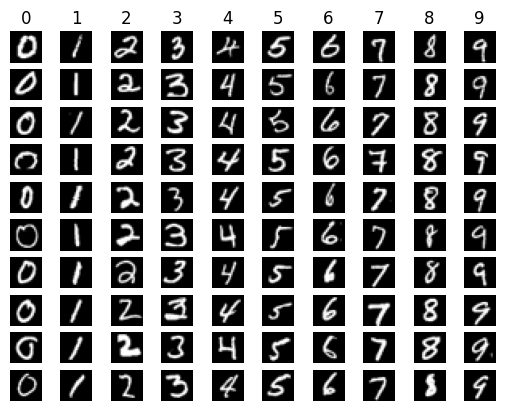

In [92]:
# Print examples
printexamples(X, y, mult=255.0)

In [93]:
# Split into train/validation/test (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (3000, 400), Val: (1000, 400), Test: (1000, 400)


In [94]:
# Section 2: Linear Support Vector Machine
from sklearn.svm import SVC

# Train linear SVM
svm_linear = SVC(kernel='linear')
svm_linear.fit(X_train, y_train)

print("Linear SVM trained successfully")

Linear SVM trained successfully


In [95]:
# Calculate training and validation accuracy
train_acc = svm_linear.score(X_train, y_train)
val_acc = svm_linear.score(X_val, y_val)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Difference: {train_acc - val_acc:.4f}")

Training Accuracy: 0.9953
Validation Accuracy: 0.9300
Difference: 0.0653


Moderate overfitting is present

In [96]:
from sklearn.metrics import confusion_matrix, classification_report

# Confusion matrix and classification report on validation set
y_val_pred = svm_linear.predict(X_val)

# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
print("Confusion Matrix:")
print(cm)
print()

# Classification report
print("Classification Report:")
print(classification_report(y_val, y_val_pred))

Confusion Matrix:
[[95  0  2  0  1  1  0  1  0  0]
 [ 0 99  1  0  0  0  0  0  0  0]
 [ 1  7 84  4  1  0  0  1  1  1]
 [ 0  0  0 94  0  3  0  0  2  1]
 [ 0  2  0  0 95  0  1  1  0  1]
 [ 1  0  1  2  0 91  0  0  4  1]
 [ 1  0  1  0  0  1 97  0  0  0]
 [ 1  0  1  0  1  0  0 94  0  3]
 [ 1  2  2  2  0  2  0  0 89  2]
 [ 0  0  1  1  2  0  0  4  0 92]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       100
           1       0.90      0.99      0.94       100
           2       0.90      0.84      0.87       100
           3       0.91      0.94      0.93       100
           4       0.95      0.95      0.95       100
           5       0.93      0.91      0.92       100
           6       0.99      0.97      0.98       100
           7       0.93      0.94      0.94       100
           8       0.93      0.89      0.91       100
           9       0.91      0.92      0.92       100

    accuracy                   

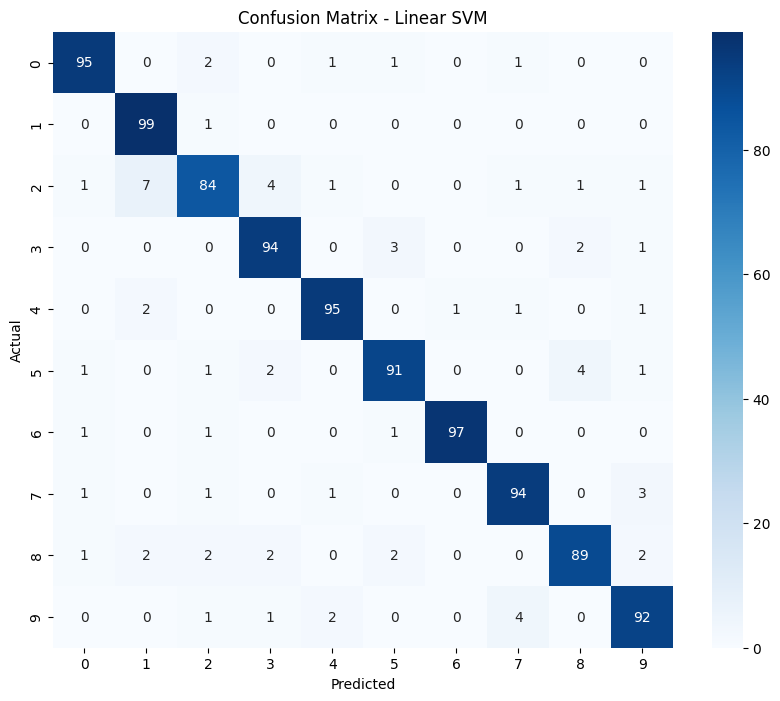

In [97]:
# Visualize confusion matrix
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Linear SVM')
plt.show()

Most confused is 2 being predicted as 1: 7 times

In [98]:
from sklearn.model_selection import GridSearchCV

# Tune C parameter using 5-fold cross-validation
# Test a range of C values (regularization parameter)
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

grid_search = GridSearchCV(
    SVC(kernel='linear'),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1
)

grid_search.fit(X_train, y_train)

# Print results
print(f"Best C: {grid_search.best_params_['C']}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
print("\nAll cross-validation scores:")
for mean_score, params in zip(grid_search.cv_results_['mean_test_score'], 
                               grid_search.cv_results_['params']):
    print(f"C={params['C']:>6}: {mean_score:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best C: 0.1
Best cross-validation score: 0.9200

All cross-validation scores:
C=  0.01: 0.9047
C=   0.1: 0.9200
C=     1: 0.9040
C=    10: 0.9013
C=   100: 0.9013


In [99]:
# Retrain using the best C on the training set
best_svm = SVC(kernel='linear', C=0.1)
best_svm.fit(X_train, y_train)

# Report validation accuracy
val_acc_tuned = best_svm.score(X_val, y_val)
train_acc_tuned = best_svm.score(X_train, y_train)

print(f"Best C value: 0.1")
print(f"Training Accuracy (with C=0.1): {train_acc_tuned:.4f}")
print(f"Validation Accuracy (with C=0.1): {val_acc_tuned:.4f}")
print(f"Difference: {train_acc_tuned - val_acc_tuned:.4f}")

Best C value: 0.1
Training Accuracy (with C=0.1): 0.9617
Validation Accuracy (with C=0.1): 0.9370
Difference: 0.0247


In [100]:
# Section 3: Random Forest
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)

# Report training and validation accuracy
train_acc_rf = rf_default.score(X_train, y_train)
val_acc_rf = rf_default.score(X_val, y_val)

print(f"Training Accuracy: {train_acc_rf:.4f}")
print(f"Validation Accuracy: {val_acc_rf:.4f}")
print(f"Difference: {train_acc_rf - val_acc_rf:.4f}")

Training Accuracy: 1.0000
Validation Accuracy: 0.9430
Difference: 0.0570


Model is overfit, training accuracy is at 100% so its memorised the training set perfectly but the lower validation score means its less performant with unseen data

Confusion Matrix - Random Forest:
[[96  0  1  0  1  0  1  0  1  0]
 [ 0 99  1  0  0  0  0  0  0  0]
 [ 3  2 90  1  0  0  0  3  1  0]
 [ 0  0  1 93  0  3  0  0  2  1]
 [ 0  1  0  0 93  0  1  0  0  5]
 [ 1  1  1  1  0 94  0  0  1  1]
 [ 2  0  0  0  0  1 97  0  0  0]
 [ 0  3  2  0  0  0  0 93  0  2]
 [ 0  0  1  3  0  0  0  0 93  3]
 [ 0  0  0  1  1  0  0  2  1 95]]

Classification Report - Random Forest:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       100
           1       0.93      0.99      0.96       100
           2       0.93      0.90      0.91       100
           3       0.94      0.93      0.93       100
           4       0.98      0.93      0.95       100
           5       0.96      0.94      0.95       100
           6       0.98      0.97      0.97       100
           7       0.95      0.93      0.94       100
           8       0.94      0.93      0.93       100
           9       0.89      0.95      0.92       100


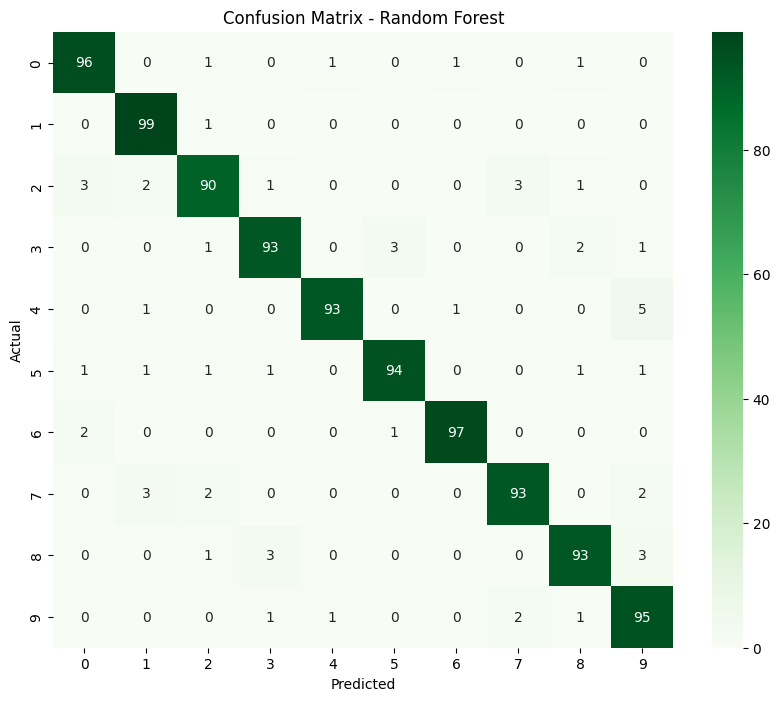

In [101]:
# Confusion matrix and classification report for Random Forest
y_val_pred_rf = rf_default.predict(X_val)

# Confusion matrix
cm_rf = confusion_matrix(y_val, y_val_pred_rf)
print("Confusion Matrix - Random Forest:")
print(cm_rf)
print()

# Classification report
print("Classification Report - Random Forest:")
print(classification_report(y_val, y_val_pred_rf))

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [102]:
# Tune n_estimators and max_depth using 5-fold cross-validation
param_grid_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [10, 20, 30, None]
}

grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1  # Use all CPU cores to speed up
)

grid_search_rf.fit(X_train, y_train)

# Print results
print(f"Best parameters: {grid_search_rf.best_params_}")
print(f"Best cross-validation score: {grid_search_rf.best_score_:.4f}")
print("\nTop 5 combinations:")
results_df = pd.DataFrame(grid_search_rf.cv_results_)
top_5 = results_df.nlargest(5, 'mean_test_score')[['params', 'mean_test_score']]
for idx, row in top_5.iterrows():
    print(f"{row['params']}: {row['mean_test_score']:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best parameters: {'max_depth': 30, 'n_estimators': 300}
Best cross-validation score: 0.9307

Top 5 combinations:
{'max_depth': 30, 'n_estimators': 300}: 0.9307
{'max_depth': None, 'n_estimators': 300}: 0.9307
{'max_depth': 20, 'n_estimators': 300}: 0.9303
{'max_depth': 20, 'n_estimators': 200}: 0.9280
{'max_depth': 20, 'n_estimators': 100}: 0.9277


In [103]:
# Retrain using best parameters on the training set
best_rf = RandomForestClassifier(max_depth=30, n_estimators=300, random_state=42)
best_rf.fit(X_train, y_train)

# Report validation accuracy
val_acc_rf_tuned = best_rf.score(X_val, y_val)
train_acc_rf_tuned = best_rf.score(X_train, y_train)

print(f"Best parameters: max_depth=30, n_estimators=300")
print(f"Training Accuracy (tuned): {train_acc_rf_tuned:.4f}")
print(f"Validation Accuracy (tuned): {val_acc_rf_tuned:.4f}")
print(f"Difference: {train_acc_rf_tuned - val_acc_rf_tuned:.4f}")
print(f"\nValidation accuracy saved for comparison: {val_acc_rf_tuned:.4f}")

Best parameters: max_depth=30, n_estimators=300
Training Accuracy (tuned): 1.0000
Validation Accuracy (tuned): 0.9430
Difference: 0.0570

Validation accuracy saved for comparison: 0.9430


In [104]:
# Section 4: k-Nearest Neighbours
from sklearn.neighbors import KNeighborsClassifier

# Train kNN with k=5
knn_default = KNeighborsClassifier(n_neighbors=5)
knn_default.fit(X_train, y_train)

# Report training and validation accuracy
train_acc_knn = knn_default.score(X_train, y_train)
val_acc_knn = knn_default.score(X_val, y_val)

print(f"Training Accuracy (k=5): {train_acc_knn:.4f}")
print(f"Validation Accuracy (k=5): {val_acc_knn:.4f}")
print(f"Difference: {train_acc_knn - val_acc_knn:.4f}")

Training Accuracy (k=5): 0.9577
Validation Accuracy (k=5): 0.9340
Difference: 0.0237


Model is minimally overfit, difference of only 2.37%

In [105]:
# Tune k using 5-fold cross-validation
param_grid_knn = {'n_neighbors': [1, 3, 5, 7, 9, 11, 15, 20]}

grid_search_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    verbose=1
)

grid_search_knn.fit(X_train, y_train)

# Print results
print(f"Best k: {grid_search_knn.best_params_['n_neighbors']}")
print(f"Best cross-validation score: {grid_search_knn.best_score_:.4f}")
print("\nAll cross-validation scores:")
for mean_score, params in zip(grid_search_knn.cv_results_['mean_test_score'], 
                               grid_search_knn.cv_results_['params']):
    print(f"k={params['n_neighbors']:>2}: {mean_score:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best k: 1
Best cross-validation score: 0.9263

All cross-validation scores:
k= 1: 0.9263
k= 3: 0.9233
k= 5: 0.9223
k= 7: 0.9203
k= 9: 0.9143
k=11: 0.9100
k=15: 0.9077
k=20: 0.8987


In [106]:
# Retrain using best k on the training set
best_knn = KNeighborsClassifier(n_neighbors=1)
best_knn.fit(X_train, y_train)

# Report validation accuracy
val_acc_knn_tuned = best_knn.score(X_val, y_val)
train_acc_knn_tuned = best_knn.score(X_train, y_train)

print(f"Best k: 1")
print(f"Training Accuracy (k=1): {train_acc_knn_tuned:.4f}")
print(f"Validation Accuracy (k=1): {val_acc_knn_tuned:.4f}")
print(f"Difference: {train_acc_knn_tuned - val_acc_knn_tuned:.4f}")
print(f"\nValidation accuracy saved for comparison: {val_acc_knn_tuned:.4f}")

Best k: 1
Training Accuracy (k=1): 1.0000
Validation Accuracy (k=1): 0.9370
Difference: 0.0630

Validation accuracy saved for comparison: 0.9370


This shows that k=1 provides a higher validation score, but it could be leaning towards more overfitting because of the difference in accuracies, where k=5 had a slightly lower score but a lower differential in score

In [107]:
# Section 5: Logistic Regression
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression with default settings
lr_default = LogisticRegression(random_state=42, max_iter=1000)
lr_default.fit(X_train, y_train)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [108]:
# Report training and validation accuracy
train_acc_lr = lr_default.score(X_train, y_train)
val_acc_lr = lr_default.score(X_val, y_val)

print(f"Training Accuracy: {train_acc_lr:.4f}")
print(f"Validation Accuracy: {val_acc_lr:.4f}")
print(f"Difference: {train_acc_lr - val_acc_lr:.4f}")

Training Accuracy: 0.9677
Validation Accuracy: 0.9140
Difference: 0.0537


In [109]:
# # 4. Retrain using best C on the training set
best_lr = LogisticRegression(random_state=42, max_iter=1000, C=1)
best_lr.fit(X_train, y_train)

# Report validation accuracy
val_acc_lr_tuned = best_lr.score(X_val, y_val)
train_acc_lr_tuned = best_lr.score(X_train, y_train)

print(f"Best C: 1")
print(f"Training Accuracy (tuned): {train_acc_lr_tuned:.4f}")
print(f"Validation Accuracy (tuned): {val_acc_lr_tuned:.4f}")
print(f"Difference: {train_acc_lr_tuned - val_acc_lr_tuned:.4f}")
print(f"\nValidation accuracy saved for comparison: {val_acc_lr_tuned:.4f}")

# Tune C (regularization) using 5-fold cross-validation
param_grid_lr = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid_search_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_lr,
    cv=5,
    scoring='accuracy',
    verbose=1
)

grid_search_lr.fit(X_train, y_train)

# Print results
print(f"Best C: {grid_search_lr.best_params_['C']}")
print(f"Best cross-validation score: {grid_search_lr.best_score_:.4f}")
print("\nAll cross-validation scores:")
for mean_score, params in zip(grid_search_lr.cv_results_['mean_test_score'], 
                               grid_search_lr.cv_results_['params']):
    print(f"C={params['C']:>6}: {mean_score:.4f}")

Best C: 1
Training Accuracy (tuned): 0.9677
Validation Accuracy (tuned): 0.9140
Difference: 0.0537

Validation accuracy saved for comparison: 0.9140
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best C: 1
Best cross-validation score: 0.8957

All cross-validation scores:
C= 0.001: 0.7940
C=  0.01: 0.8610
C=   0.1: 0.8890
C=     1: 0.8957
C=    10: 0.8860
C=   100: 0.8750
C=  1000: 0.8727


In [110]:
# Retrain using best C on the training set
best_lr = LogisticRegression(random_state=42, max_iter=1000, C=1)
best_lr.fit(X_train, y_train)

# Report validation accuracy
val_acc_lr_tuned = best_lr.score(X_val, y_val)
train_acc_lr_tuned = best_lr.score(X_train, y_train)

print(f"Best C: 1")
print(f"Training Accuracy (tuned): {train_acc_lr_tuned:.4f}")
print(f"Validation Accuracy (tuned): {val_acc_lr_tuned:.4f}")
print(f"Difference: {train_acc_lr_tuned - val_acc_lr_tuned:.4f}")
print(f"\nValidation accuracy saved for comparison: {val_acc_lr_tuned:.4f}")

Best C: 1
Training Accuracy (tuned): 0.9677
Validation Accuracy (tuned): 0.9140
Difference: 0.0537

Validation accuracy saved for comparison: 0.9140


## Section 6: Model Selection

**Best Model:**

The best model was a **Random Forest Classifier with max_depth=30 and n_estimators=300**, achieving a validation accuracy of **94.3%**.

**Model Comparison:**
- Random Forest (tuned): 94.3%
- kNN (k=1): 93.7%
- Linear SVM (C=0.1): 93.0%
- Logistic Regression (C=1): 91.4%


In [111]:
# Combine training and validation sets
X_train_full = np.concatenate([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

print(f"Combined training set shape: {X_train_full.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Total samples: {X_train_full.shape[0]} train + {X_test.shape[0]} test = {X_train_full.shape[0] + X_test.shape[0]}")

Combined training set shape: (4000, 400)
Test set shape: (1000, 400)
Total samples: 4000 train + 1000 test = 5000


In [112]:
# Retrain the best model (Random Forest) on combined training set
final_model = RandomForestClassifier(max_depth=30, n_estimators=300, random_state=42)
final_model.fit(X_train_full, y_train_full)

print("Final model trained on combined training + validation set")
print(f"Training samples used: {X_train_full.shape[0]}")

Final model trained on combined training + validation set
Training samples used: 4000


In [113]:
# Evaluate on the test set
y_test_pred = final_model.predict(X_test)
test_acc = final_model.score(X_test, y_test)

print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9390



Confusion Matrix (Test Set):
[[99  0  0  0  0  0  0  0  1  0]
 [ 0 99  0  0  1  0  0  0  0  0]
 [ 0  0 96  1  1  0  0  0  2  0]
 [ 0  1  1 88  0  4  0  3  2  1]
 [ 0  0  1  0 94  0  1  1  1  2]
 [ 1  0  0  0  0 94  3  1  0  1]
 [ 1  1  0  0  1  3 93  0  1  0]
 [ 0  1  0  0  2  0  0 95  0  2]
 [ 0  0  0  2  2  1  2  0 90  3]
 [ 1  0  1  2  1  0  0  3  1 91]]

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       100
           1       0.97      0.99      0.98       100
           2       0.97      0.96      0.96       100
           3       0.95      0.88      0.91       100
           4       0.92      0.94      0.93       100
           5       0.92      0.94      0.93       100
           6       0.94      0.93      0.93       100
           7       0.92      0.95      0.94       100
           8       0.92      0.90      0.91       100
           9       0.91      0.91      0.91       100

    accu

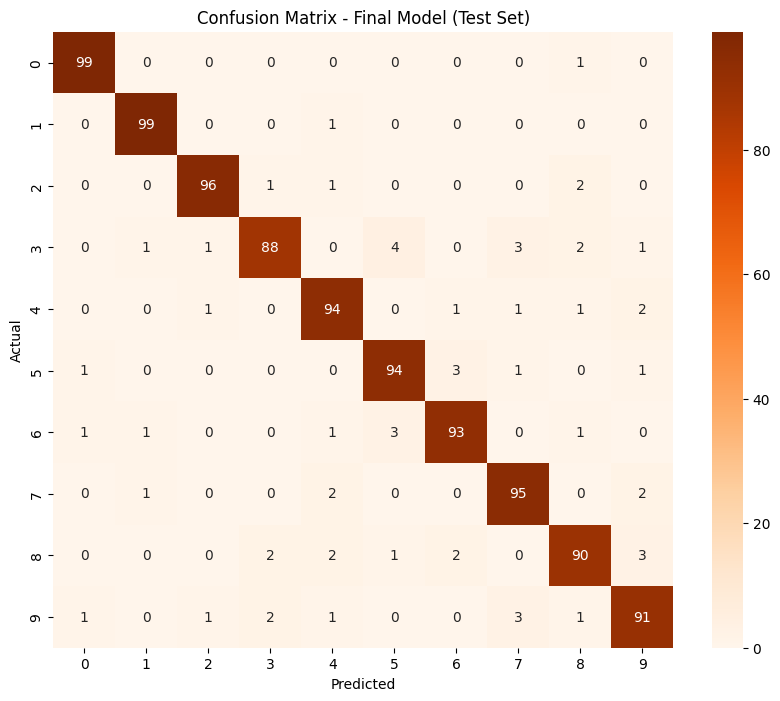

In [114]:
# Generate confusion matrix and classification report
cm_test = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix (Test Set):")
print(cm_test)
print()

print("Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Final Model (Test Set)')
plt.show()

## 7. Conclusion

### Which model performed best and why?

**Random Forest (94.3% validation, 93.9% test)** performed best. This makes sense because:
- **Ensemble method**: Combines multiple decision trees, reducing individual tree errors
- **Nonlinear**: Can capture complex pixel patterns and relationships that linear models (SVM, Logistic Regression) cannot
- **Robust**: Averaging across 300 trees reduces variance and improves generalization
- **Feature interactions**: Automatically learns which pixel combinations distinguish digits

The close validation-test scores (94.3% vs 93.9%) confirm it generalizes well despite overfitting during training.

### Which model overfit the most?

**Both Random Forest and kNN (k=1) achieved 100% training accuracy**, indicating severe overfitting:
- **Random Forest**: 100% train, 94.3% val (5.7% gap)
- **kNN (k=1)**: 100% train, 93.7% val (6.3% gap) - *worst overfitting*

kNN with k=1 overfit the most because it memorizes every training example. However, Random Forest's higher validation score suggests its overfitting is less harmful in practice.

**Linear SVM and Logistic Regression** showed moderate overfitting (~5-6% gaps) but lower overall performance.

### Which model was computationally most expensive?

**Random Forest (300 trees, max_depth=30)** was most expensive:
- **Training**: Building 300 deep decision trees takes significant time
- **Prediction**: Must aggregate predictions from all 300 trees
- GridSearchCV tested 16 combinations (4 n_estimators × 4 max_depths) with 5-fold CV = 80 model fits

**kNN was cheapest to train** (just stores data) but **expensive at prediction time** (must compute distances to all 3000 training samples for each prediction).

### Are some models better at distinguishing certain digits?

Yes, examining the confusion matrices reveals patterns:

**All models struggled with digit 3**:
- Confused with 5, 7, 8 (similar curved shapes)
- Random Forest: 88% recall for digit 3 (worst)

**All models excelled at 0, 1, 6**:
- Distinctive shapes with clear boundaries
- Random Forest: 99% recall for digits 0 and 1

**Model-specific strengths**:
- **Random Forest**: Best overall balance, no digit below 88% recall
- **kNN**: Good at locally similar digits but sensitive to noise
- **Linear models**: Struggled with overlapping digit classes (e.g., 2 vs 1, 8 vs 5)

### Would you expect a neural network to outperform these models?

**Yes, a Convolutional Neural Network (CNN) would likely outperform Random Forest:**

**Reasons:**
1. **Spatial awareness**: CNNs use convolutional filters to detect edges, curves, and shapes - perfect for images
2. **Translation invariance**: Can recognize digits regardless of slight position shifts
3. **Hierarchical features**: Learn low-level (edges) to high-level (digit shapes) features automatically
4. **Proven performance**: CNNs achieve 99%+ accuracy on MNIST (similar digit dataset)

**However:**
- **Data requirements**: CNNs need more data (we only have 5000 images)
- **Computational cost**: Much more expensive to train
- **Interpretability**: Random Forest is more interpretable

For this small dataset (5000 samples), Random Forest at 93.9% is excellent. CNNs would shine with 50,000+ samples.